In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import statsmodels.formula.api as sm
from sklearn.linear_model import LinearRegression
from yellowbrick.regressor import ResidualsPlot

In [4]:
base = pd.read_csv('data/slr12.csv', sep=';')
base.head()

,FrqAnual,CusInic
0,1000,1050
1,1125,1150
2,1087,1213
3,1070,1275
4,1100,1300


In [8]:
base_correlacao = base.corr()
base_correlacao

#Correlação de nível médio para baixo

,FrqAnual,CusInic
FrqAnual,1.000000,0.477007
CusInic,0.477007,1.000000


In [11]:
x = base.iloc[: , 0].values
y = base.iloc[: , 1].values
x

array([1000, 1125, 1087, 1070, 1100, 1150, 1250, 1150, 1100, 1350, 1275,
       1375, 1175, 1200, 1175, 1300, 1260, 1330, 1325, 1200, 1225, 1090,
       1075, 1080, 1080, 1180, 1225, 1175, 1250, 1250,  750, 1125,  700,
        900,  900,  850])

In [19]:
correlacao = np.corrcoef(x, y)
correlacao


(36,)

In [23]:
x = x.reshape(-1, 1)

modelo = LinearRegression()
modelo.fit(x, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
modelo.intercept_

np.float64(867.6042222620558)

In [25]:
modelo.coef_

array([0.37315794])

Text(0.5, 0, 'Taxa Anual')

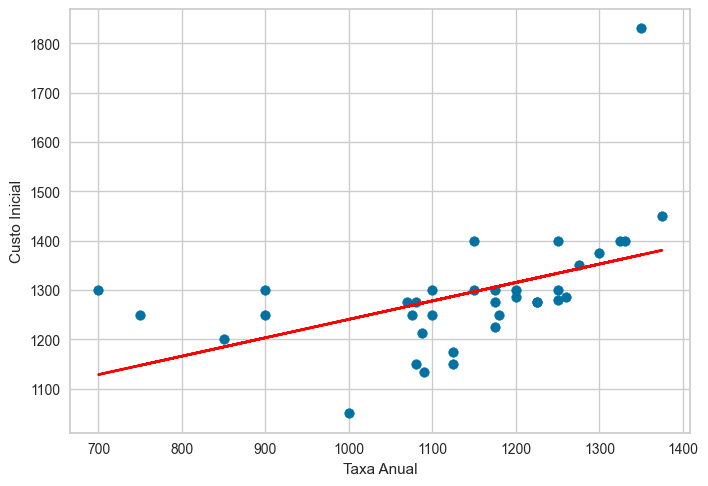

In [27]:
plt.scatter(x, y)
plt.plot(x, modelo.predict(x), color = 'red')
modelo.fit(x, y)
plt.ylabel('Custo Inicial')
plt.xlabel('Taxa Anual')

In [30]:
modelo.score(x, y)

0.2275359181555101

In [32]:
modelo_ajustado = sm.ols(formula='CusInic ~ FrqAnual', data= base)
modelo_treinado = modelo_ajustado.fit()
modelo_treinado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                CusInic   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     10.01
Date:                Mon, 16 Mar 2026   Prob (F-statistic):            0.00327
Time:                        23:23:42   Log-Likelihood:                -219.47
No. Observations:                  36   AIC:                             442.9
Df Residuals:                      34   BIC:                             446.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    867.6042    135.071      6.423      0.000     593.107    1142.102
FrqAnual       0.3732      0.118      3.165      0.003       0.134       0.613
==============================================================================
Omnibus:                       32.231   Durbin-Watson:                   1.740
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               96.481
Skew:                           1.975   Prob(JB):                     1.12e-21
Kurtosis:                       9.979   Cond. No.                     8.39e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.39e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [35]:
previsoes = modelo.predict(x)
previsoes

array([1240.76215819, 1287.40690018, 1273.22689862, 1266.88321371,
       1278.07795178, 1296.73584858, 1334.05164217, 1296.73584858,
       1278.07795178, 1371.36743577, 1343.38059057, 1380.69638416,
       1306.06479698, 1315.39374538, 1306.06479698, 1352.70953897,
       1337.78322153, 1363.90427705, 1362.03848737, 1315.39374538,
       1324.72269377, 1274.34637242, 1268.74900339, 1270.61479307,
       1270.61479307, 1307.93058666, 1324.72269377, 1306.06479698,
       1334.05164217, 1334.05164217, 1147.47267421, 1287.40690018,
       1128.81477741, 1203.4463646 , 1203.4463646 , 1184.7884678 ])

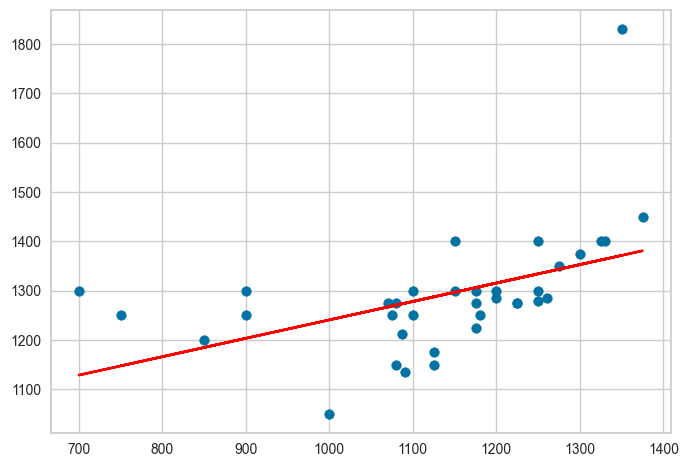

In [36]:
plt.scatter(x, y)
plt.plot(x, previsoes, color= 'red')